# Medical Insurance Cost Prediction

## Phase 3: Data Preprocessing and Model Training

This notebook builds a complete machine learning pipeline including:

- Data preprocessing
- Feature engineering
- Model training
- Model evaluation
- Model comparison

In [1]:
# Data manipulation

import pandas as pd
import numpy as np

In [2]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

# Machine Learning

from sklearn.model_selection import train_test_split


# Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


# Pipeline

from sklearn.pipeline import Pipeline


# Models

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.ensemble import GradientBoostingRegressor


# Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Saving model

import joblib

import json

## Loading Dataset

The dataset contains medical insurance information.

Features:

- age
- sex
- bmi
- children
- smoker
- region

Target:

- charges

In [4]:
# Load Dataset
df = pd.read_csv("../data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [5]:
df.shape

(1338, 7)

## Feature Target Separation

The target variable is insurance charges.

X contains independent variables.

y contains the dependent variable.

In [7]:
# Separate Features and Target
X = df.drop("expenses", axis=1)

y = df["expenses"]

In [8]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.9,0,yes,southwest
1,18,male,33.8,1,no,southeast
2,28,male,33.0,3,no,southeast
3,33,male,22.7,0,no,northwest
4,32,male,28.9,0,no,northwest


In [9]:
y.head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64

## Splitting Dataset

We divide the dataset into:

- 80% Training Data
- 20% Testing Data

Training data is used to learn patterns.

Testing data evaluates model performance.

In [10]:
# Train Test Spilt
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(1070, 6)
(268, 6)


## Identifying Numerical and Categorical Features

Machine learning algorithms require numerical input.

Therefore:

Numerical Features:
- age
- bmi
- children

Categorical Features:
- sex
- smoker
- region

Categorical variables will be converted using One Hot Encoding.
Numerical variables will be standardized.

In [12]:
numerical_features = [
    "age",
    "bmi",
    "children"
]


categorical_features = [
    "sex",
    "smoker",
    "region"
]

# Create Preprocessor
## Creating Column Transformer

ColumnTransformer allows applying different transformations to different columns.

Numerical Pipeline:

StandardScaler()

Categorical Pipeline:

OneHotEncoder()

In [13]:
preprocessor = ColumnTransformer(
    
    transformers=[
        
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        
        (
            "cat",
            OneHotEncoder(),
            categorical_features
        )
        
    ]
)

In [14]:
# Text Preprocessing
X_train_transformed = preprocessor.fit_transform(X_train)

X_train_transformed.shape

(1070, 11)

# Building Machine Learning Pipelines

A pipeline combines:

1. Data preprocessing
2. Machine learning model

Advantages:

- Prevents data leakage
- Keeps preprocessing consistent
- Makes deployment easier
- Allows saving the complete model

## Model 1: Linear Regression

Linear Regression assumes a linear relationship between input features and insurance charges.

It is used as a baseline regression model.

In [15]:
lr_pipeline = Pipeline(

    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            LinearRegression()
        )
        
    ]

)

In [16]:
# check pipeline
lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## Model 2: Ridge Regression

Ridge Regression is Linear Regression with L2 regularization.

It reduces overfitting by adding a penalty term to large coefficients.

In [17]:
ridge_pipeline = Pipeline(

    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            Ridge()
        )
        
    ]

)

## Model 3: Gradient Boosting Regressor

Gradient Boosting is an ensemble learning algorithm.

It combines multiple weak learners (decision trees) to create a strong predictive model.

It can capture complex relationships between features and insurance charges.

In [19]:
gb_pipeline = Pipeline(

    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            GradientBoostingRegressor()
        )
        
    ]

)

# Store Models in Dictionary
## Creating Model Dictionary

Instead of training models separately, we store them in a dictionary.

This makes model evaluation automated.

In [20]:
models = {

    "Linear Regression": lr_pipeline,

    "Ridge Regression": ridge_pipeline,

    "Gradient Boosting": gb_pipeline

}

In [21]:
models.keys()

dict_keys(['Linear Regression', 'Ridge Regression', 'Gradient Boosting'])

# Model Training

Each pipeline performs:

1. Feature preprocessing
2. Model fitting

The test data remains unseen during training.

In [22]:
for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    print(f"{name} trained successfully")

Linear Regression trained successfully
Ridge Regression trained successfully
Gradient Boosting trained successfully


# Generating Predictions

After training, models predict insurance charges for unseen test data.

In [23]:
predictions = {}

for name, model in models.items():

    predictions[name] = model.predict(X_test)

In [24]:
predictions.keys()

dict_keys(['Linear Regression', 'Ridge Regression', 'Gradient Boosting'])

# Model Evaluation

We evaluate all regression models using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [25]:
# Create Evaluation Function
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

In [26]:
# Evaluate All Models
results = []


for name, pred in predictions.items():

    mae, rmse, r2 = evaluate_model(
        y_test,
        pred
    )

    results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }
    )

In [27]:
# Convert Results into DataFrame
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4181.561524,5796.556336,0.783573
1,Ridge Regression,4187.274297,5798.567490,0.783422
2,Gradient Boosting,2408.751685,4328.692068,0.879306


In [28]:
# Sort Best Model
results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,2408.751685,4328.692068,0.879306
0,Linear Regression,4181.561524,5796.556336,0.783573
1,Ridge Regression,4187.274297,5798.567490,0.783422


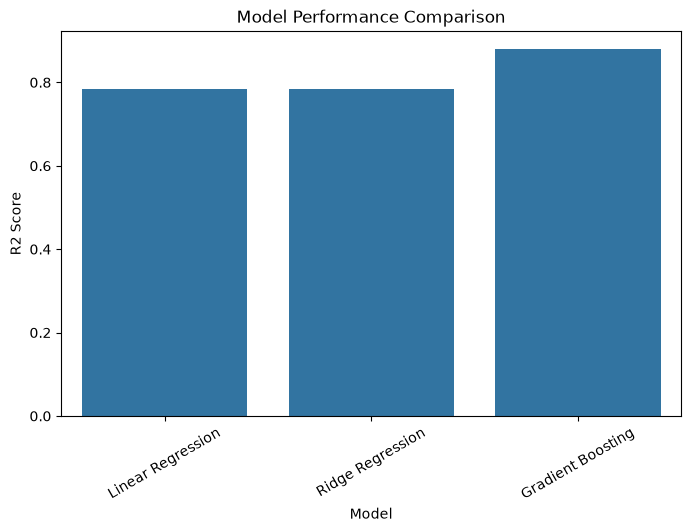

In [29]:
# Visualization: Model Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title(
    "Model Performance Comparison"
)

plt.xticks(rotation=30)

plt.show()

In [31]:
# Save Metrics
metrics = results_df.to_dict(
    orient="records"
)


with open(
    "../artifacts/metrics.json",
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )

# Selecting Best Performing Model

The best regression model is selected based on the highest R² score.

A higher R² value indicates that the model explains more variance in insurance charges.

In [32]:
best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]


best_model_name

'Gradient Boosting'

In [33]:
# Retrieve Best Pipeline
best_model = models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

# Saving Final Model

The complete pipeline is saved.

It contains:

1. Feature preprocessing
2. Encoding
3. Scaling
4. Regression model

This allows prediction on raw input data directly.

In [34]:
joblib.dump(
    best_model,
    "../artifacts/model.pkl"
)

['../artifacts/model.pkl']

In [35]:
joblib.dump(
    preprocessor,
    "../artifacts/preprocessor.pkl"
)

['../artifacts/preprocessor.pkl']

# Testing Saved Model

We reload the model from disk and verify that predictions work correctly.

In [37]:
loaded_model = joblib.load(
    "../artifacts/model.pkl"
)

In [38]:
sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)


sample_prediction

array([11421.6714098 ,  5808.63037282, 27906.9183161 ,  9681.11044612,
       34047.0200666 ])

In [39]:
# Save Final Model Information
model_info = {

    "best_model": best_model_name,

    "features": list(X.columns),

    "target": "charges"

}


with open(
    "../artifacts/model_info.json",
    "w"
) as file:

    json.dump(
        model_info,
        file,
        indent=4
    )

In [40]:
# Final Notebook Check
import os

os.listdir("../artifacts")

['metrics.json', 'model.pkl', 'model_info.json', 'preprocessor.pkl']